In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
import warnings

In [4]:
warnings.filterwarnings("ignore")

ACCENT_PALETTE = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657', '#79c0ff', '#f85149', '#56d4dd']

plt.rcParams.update({
    'figure.facecolor': '#0d1117',

    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'axes.titlecolor': '#e6edf3',
    'axes.prop_cycle': plt.cycler(color=ACCENT_PALETTE),

    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',

    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.color': '#cccccc',
    'grid.linestyle': "--",
    'grid.alpha': 0.75,

    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',

    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
})

sns.set_palette(ACCENT_PALETTE)

In [6]:
def load_data(path: str) -> pd.DataFrame:
    data_path = Path(path)

    if not data_path.exists():
        raise FileNotFoundError(f'{data_path} does not exist')

    return pd.read_csv(data_path)

cast = load_data("../data/raw-data/raw-marvel-cast.csv")
master = load_data("../data/raw-data/raw-marvel-master.csv")
rag = load_data("../data/raw-data/raw-marvel-rag.csv")
ratings = load_data("../data/raw-data/raw-marvel-ratings.csv")

In [7]:
print("==========SHAPE==========\n")
print(f"Cast: {cast.shape}")
print(f"Master: {master.shape}")
print(f"Rag: {rag.shape}")
print(f"Ratings: {ratings.shape}")

==========SHAPE==========

Cast: (1628, 9)
Master: (161, 50)
Rag: (161, 6)
Ratings: (554, 4)


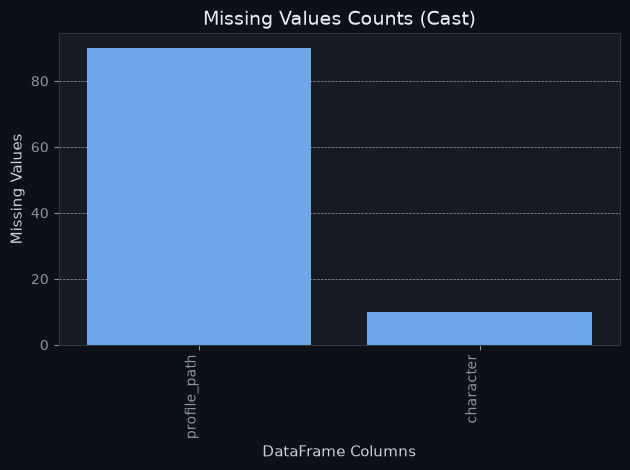

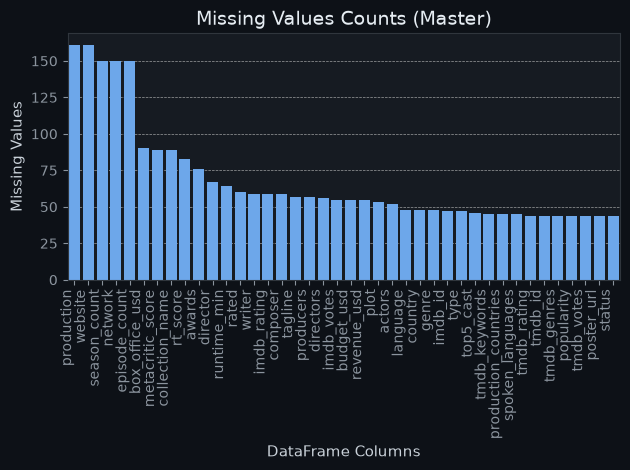

No missing values Rag


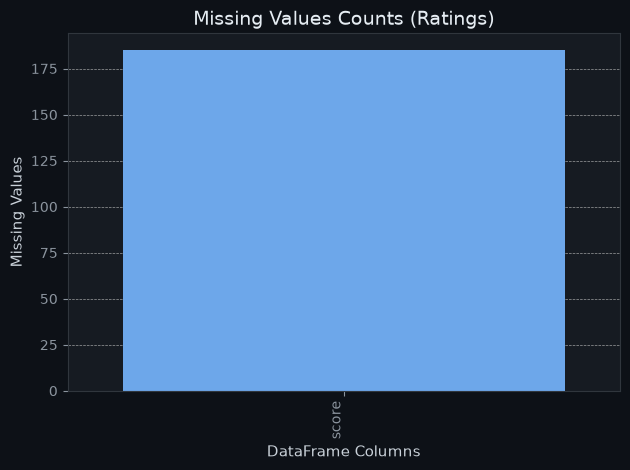

==========TOTAL NANS==========
Total NaNs: 3019


In [16]:
def make_missing_barplot(data: pd.DataFrame, name: str=""):
    missing_counts = data.isna().sum()
    missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

    if missing_counts.empty:
        print(f"No missing values {name}")
        return missing_counts

    sns.barplot(x=missing_counts.index, y=missing_counts.values)
    plt.xticks(rotation=90, ha='right')
    plt.title(f"Missing Values Counts ({name})")
    plt.xlabel("DataFrame Columns")
    plt.ylabel("Missing Values")

    plt.tight_layout()
    plt.show()
    return missing_counts

missing_cast = make_missing_barplot(cast, name="Cast")
missing_master = make_missing_barplot(master, name="Master")
missing_rag = make_missing_barplot(rag, name="Rag")
missing_ratings = make_missing_barplot(ratings, name="Ratings")

total_missing = sum(s.sum() for s in [missing_cast, missing_master, missing_rag, missing_ratings] if s is not None)
print("==========TOTAL NANS==========")
print(f"Total NaNs: {total_missing}")